You can upload files from your local computer to the Colab environment. When you run the code, a button will appear that allows you to select files from your local system.

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

In [ ]:
import pandas as pd

df = pd.read_csv('enhanced_menstrual_cycle_dataset.csv')
# display(df.head())
print(df.columns)

Index(['User_ID', 'Age', 'BMI', 'Age_At_Menarche', 'Family_History_Irregular',
       'Has_PCOS_Background', 'Smoking_Status', 'Prev_1_Cycle_Length',
       'Prev_2_Cycle_Length', 'Prev_3_Cycle_Length', 'Prev_1_Irregular_Flag',
       'Prev_2_Irregular_Flag', 'Prev_3_Irregular_Flag',
       'Prev_1_Period_Length', 'Prev_2_Period_Length', 'Prev_3_Period_Length',
       'Exercise_Frequency', 'Sleep_Hours', 'Diet_Type', 'Stress_Level',
       'Alcohol_Consumption', 'Caffeine_Intake', 'Medication_Contraceptive',
       'Symptom_Cramps_Current', 'Symptom_Headache_Current',
       'Symptom_Fatigue_Current', 'Symptom_Bloating_Current',
       'Symptom_Mood_Swings_Current', 'Symptom_Acne_Current',
       'Next_Cycle_Length', 'Next_Is_Irregular', 'Next_Period_Length',
       'Confidence_Score'],
      dtype='object')


In [ ]:
# missing_values = df.isnull().sum()
# display(missing_values[missing_values > 0])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   User_ID                      20000 non-null  int64  
 1   Age                          20000 non-null  int64  
 2   BMI                          20000 non-null  float64
 3   Age_At_Menarche              20000 non-null  int64  
 4   Family_History_Irregular     20000 non-null  int64  
 5   Has_PCOS_Background          20000 non-null  int64  
 6   Smoking_Status               20000 non-null  int64  
 7   Prev_1_Cycle_Length          20000 non-null  int64  
 8   Prev_2_Cycle_Length          20000 non-null  int64  
 9   Prev_3_Cycle_Length          20000 non-null  int64  
 10  Prev_1_Irregular_Flag        20000 non-null  int64  
 11  Prev_2_Irregular_Flag        20000 non-null  int64  
 12  Prev_3_Irregular_Flag        20000 non-null  int64  
 13  Prev_1_Period_Le

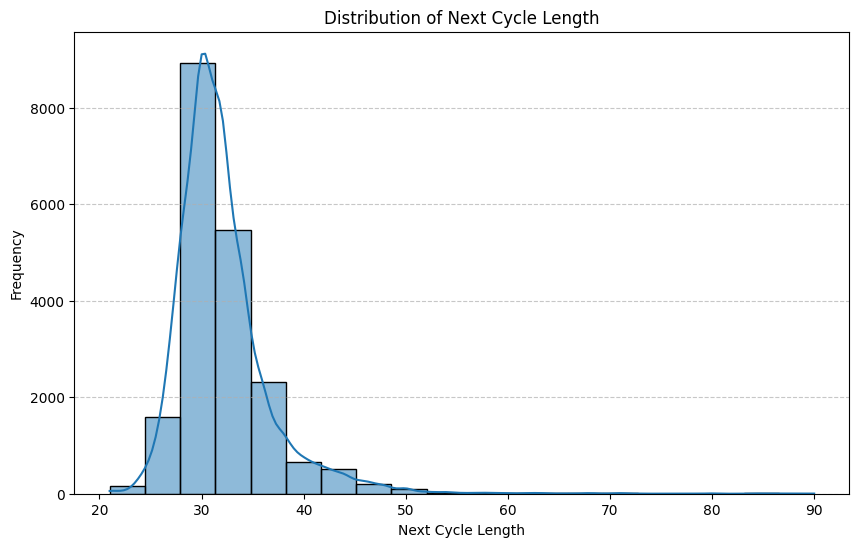

In [ ]:
# how we will implies this most of population are of 30 days
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Next_Cycle_Length'], bins=20, kde=True)
plt.title('Distribution of Next Cycle Length')
plt.xlabel('Next Cycle Length')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
grouped_data = df.groupby('Next_Is_Irregular').mean(numeric_only=True)
display(grouped_data)

,User_ID,Age,BMI,Age_At_Menarche,Family_History_Irregular,Has_PCOS_Background,Smoking_Status,Prev_1_Cycle_Length,Prev_2_Cycle_Length,Prev_3_Cycle_Length,...,Medication_Contraceptive,Symptom_Cramps_Current,Symptom_Headache_Current,Symptom_Fatigue_Current,Symptom_Bloating_Current,Symptom_Mood_Swings_Current,Symptom_Acne_Current,Next_Cycle_Length,Next_Period_Length,Confidence_Score
Next_Is_Irregular,,,,,,,,,,,,,,,,,,,,,
0,499.590758,30.774572,26.729375,12.486446,0.208148,0.092898,0.150999,30.134908,28.665663,27.028139,...,0.198874,0.406706,0.404962,0.401791,0.394658,0.400285,0.398066,31.071972,5.503171,0.825396
1,502.053494,30.840737,26.837243,12.496073,0.207746,0.095883,0.151002,31.006365,29.174702,27.603196,...,0.199892,0.394231,0.409263,0.398564,0.403304,0.404794,0.399919,33.762730,5.495531,0.826094


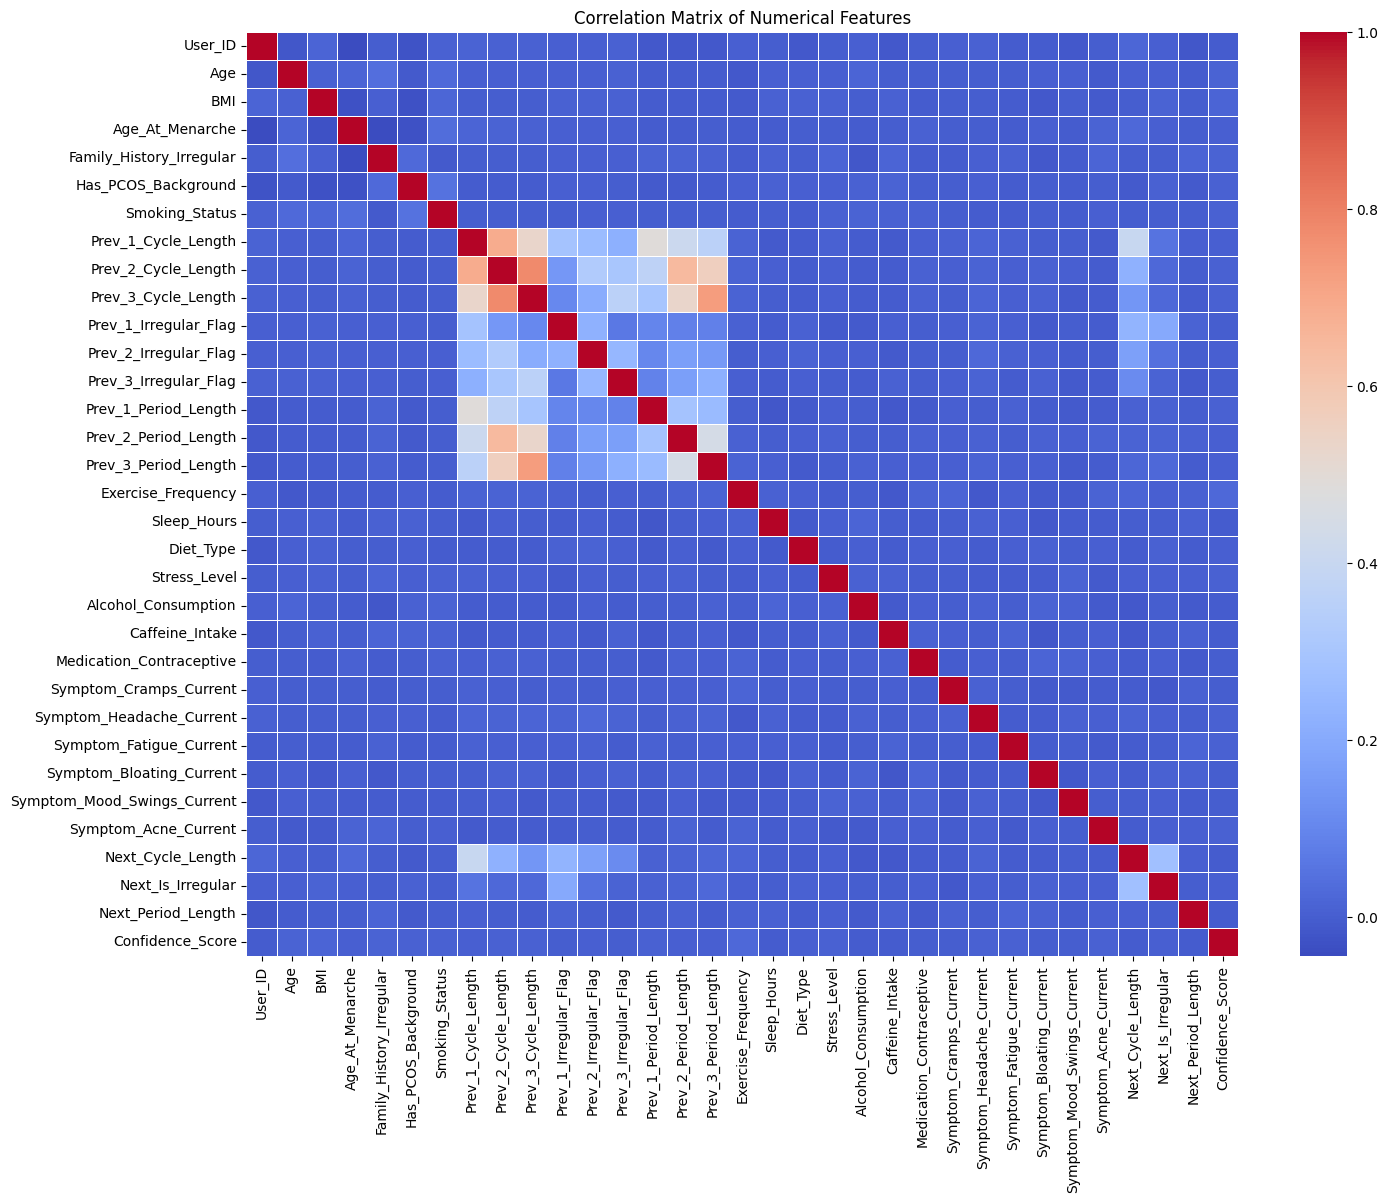

In [ ]:
# no need hami lay tala feature remove garya chau , useless data
plt.figure(figsize=(16, 12))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
correlations_with_next_cycle_length = correlation_matrix['Next_Cycle_Length'].sort_values(ascending=False)

# Exclude self-correlation and display top 10
display(correlations_with_next_cycle_length.drop('Next_Cycle_Length').head(10))

,Next_Cycle_Length
Prev_1_Cycle_Length,0.396832
Next_Is_Irregular,0.274150
Prev_1_Irregular_Flag,0.230837
Prev_2_Cycle_Length,0.223067
Prev_2_Irregular_Flag,0.168603
Prev_3_Cycle_Length,0.140442
Prev_3_Irregular_Flag,0.114060
Age_At_Menarche,0.023302
User_ID,0.017567
Prev_3_Period_Length,0.017507


In [ ]:
print("\nTop 10 features negatively correlated with Next_Cycle_Length:")
display(correlations_with_next_cycle_length.drop('Next_Cycle_Length').tail(10))


Top 10 features negatively correlated with Next_Cycle_Length:


,Next_Cycle_Length
Symptom_Cramps_Current,-0.003357
Confidence_Score,-0.003609
Symptom_Acne_Current,-0.003871
Symptom_Bloating_Current,-0.004106
Medication_Contraceptive,-0.004615
Diet_Type,-0.004896
Symptom_Fatigue_Current,-0.005665
Has_PCOS_Background,-0.010054
Caffeine_Intake,-0.012220
Alcohol_Consumption,-0.015133


In [ ]:
columns_to_keep = [
    'Age', 'BMI', 'Age_At_Menarche', 'Family_History_Irregular',
    'Has_PCOS_Background', 'Prev_1_Cycle_Length', 'Prev_2_Cycle_Length',
    'Prev_3_Cycle_Length', 'Prev_1_Irregular_Flag', 'Prev_2_Irregular_Flag',
    'Prev_3_Irregular_Flag', 'Prev_1_Period_Length', 'Prev_2_Period_Length',
    'Prev_3_Period_Length', 'Exercise_Frequency', 'Sleep_Hours',
    'Diet_Type', 'Stress_Level', 'Symptom_Cramps_Current',
    'Symptom_Headache_Current', 'Symptom_Fatigue_Current',
    'Symptom_Bloating_Current', 'Symptom_Mood_Swings_Current',
    'Symptom_Acne_Current',
    'Next_Cycle_Length', 'Next_Is_Irregular', 'Next_Period_Length'
]

df = df[columns_to_keep]
display(df.head())
print(df.columns)

,Age,BMI,Age_At_Menarche,Family_History_Irregular,Has_PCOS_Background,Prev_1_Cycle_Length,Prev_2_Cycle_Length,Prev_3_Cycle_Length,Prev_1_Irregular_Flag,Prev_2_Irregular_Flag,...,Stress_Level,Symptom_Cramps_Current,Symptom_Headache_Current,Symptom_Fatigue_Current,Symptom_Bloating_Current,Symptom_Mood_Swings_Current,Symptom_Acne_Current,Next_Cycle_Length,Next_Is_Irregular,Next_Period_Length
0,24,31.6,15,0,0,0,0,0,0,0,...,5,0,0,0,0,0,0,34,0,5
1,24,31.6,15,0,0,34,0,0,0,0,...,3,1,1,0,0,1,0,34,0,6
2,24,31.6,15,0,0,34,34,0,0,0,...,3,0,0,0,0,1,1,31,0,6
3,24,31.6,15,0,0,31,34,34,0,0,...,5,0,0,0,1,0,1,32,1,8
4,24,31.6,15,0,0,32,31,34,1,0,...,3,1,1,0,0,0,0,32,0,5


Index(['Age', 'BMI', 'Age_At_Menarche', 'Family_History_Irregular',
       'Has_PCOS_Background', 'Prev_1_Cycle_Length', 'Prev_2_Cycle_Length',
       'Prev_3_Cycle_Length', 'Prev_1_Irregular_Flag', 'Prev_2_Irregular_Flag',
       'Prev_3_Irregular_Flag', 'Prev_1_Period_Length', 'Prev_2_Period_Length',
       'Prev_3_Period_Length', 'Exercise_Frequency', 'Sleep_Hours',
       'Diet_Type', 'Stress_Level', 'Symptom_Cramps_Current',
       'Symptom_Headache_Current', 'Symptom_Fatigue_Current',
       'Symptom_Bloating_Current', 'Symptom_Mood_Swings_Current',
       'Symptom_Acne_Current', 'Next_Cycle_Length', 'Next_Is_Irregular',
       'Next_Period_Length'],
      dtype='object')


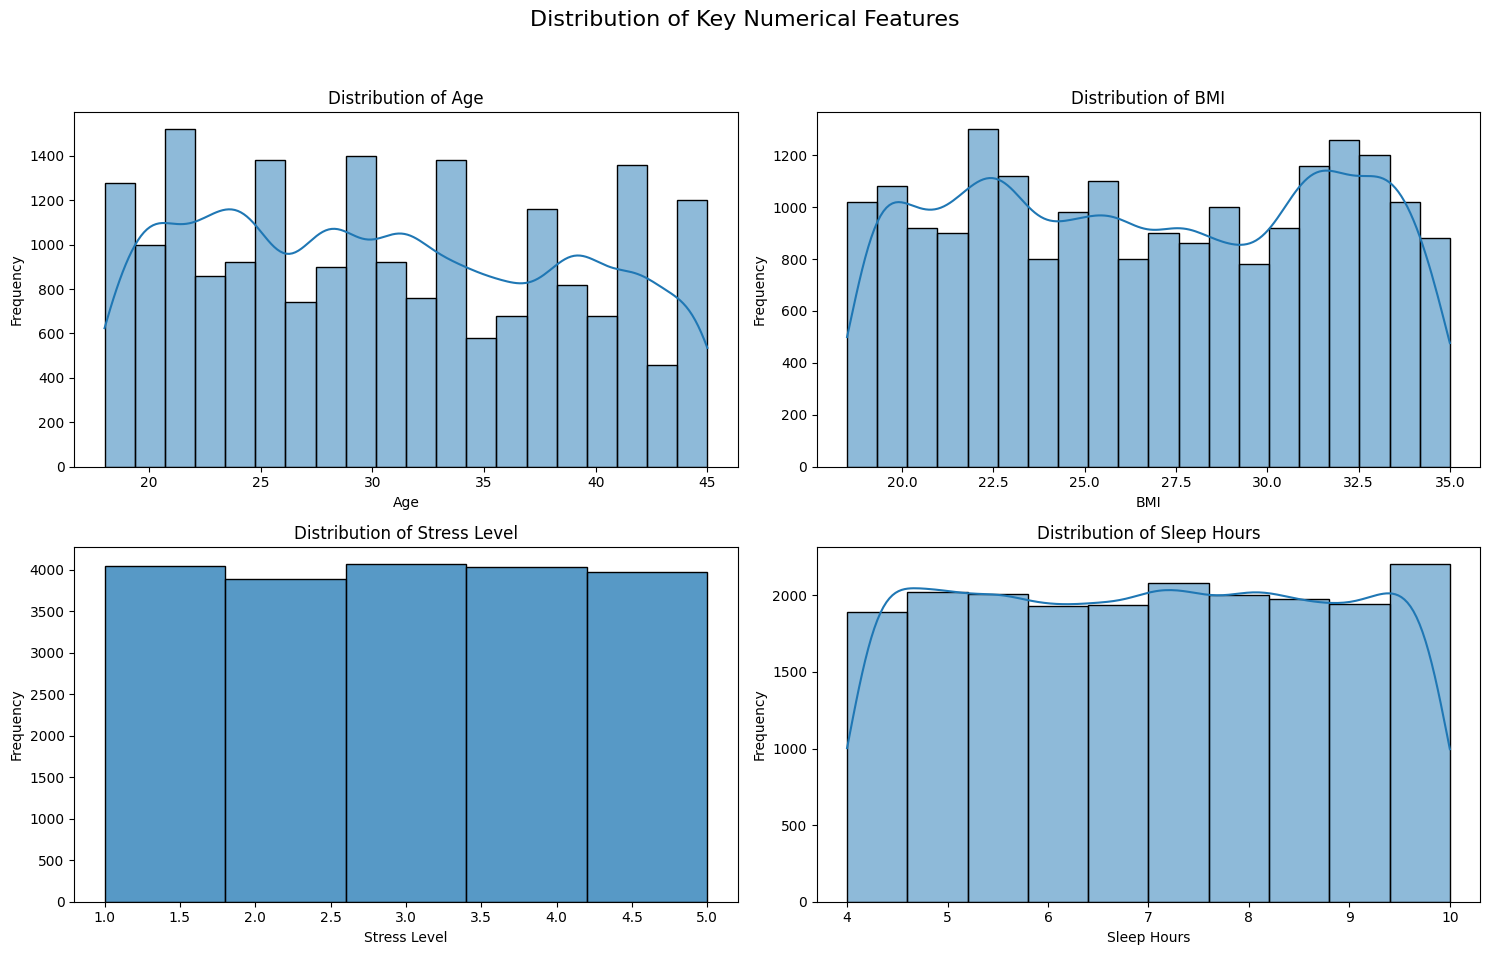

In [ ]:
# not so important for our project ; its for heath concern of country
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes for subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Key Numerical Features', fontsize=16)

# Distribution of Age
sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Age')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# Distribution of BMI
sns.histplot(df['BMI'], bins=20, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of BMI')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('Frequency')

# Distribution of Stress_Level
sns.histplot(df['Stress_Level'], bins=5, kde=False, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Stress Level')
axes[1, 0].set_xlabel('Stress Level')
axes[1, 0].set_ylabel('Frequency')

# Distribution of Sleep_Hours
sns.histplot(df['Sleep_Hours'], bins=10, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Sleep Hours')
axes[1, 1].set_xlabel('Sleep Hours')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

Next, let's look at how the presence of PCOS background and stress levels might influence cycle regularity.

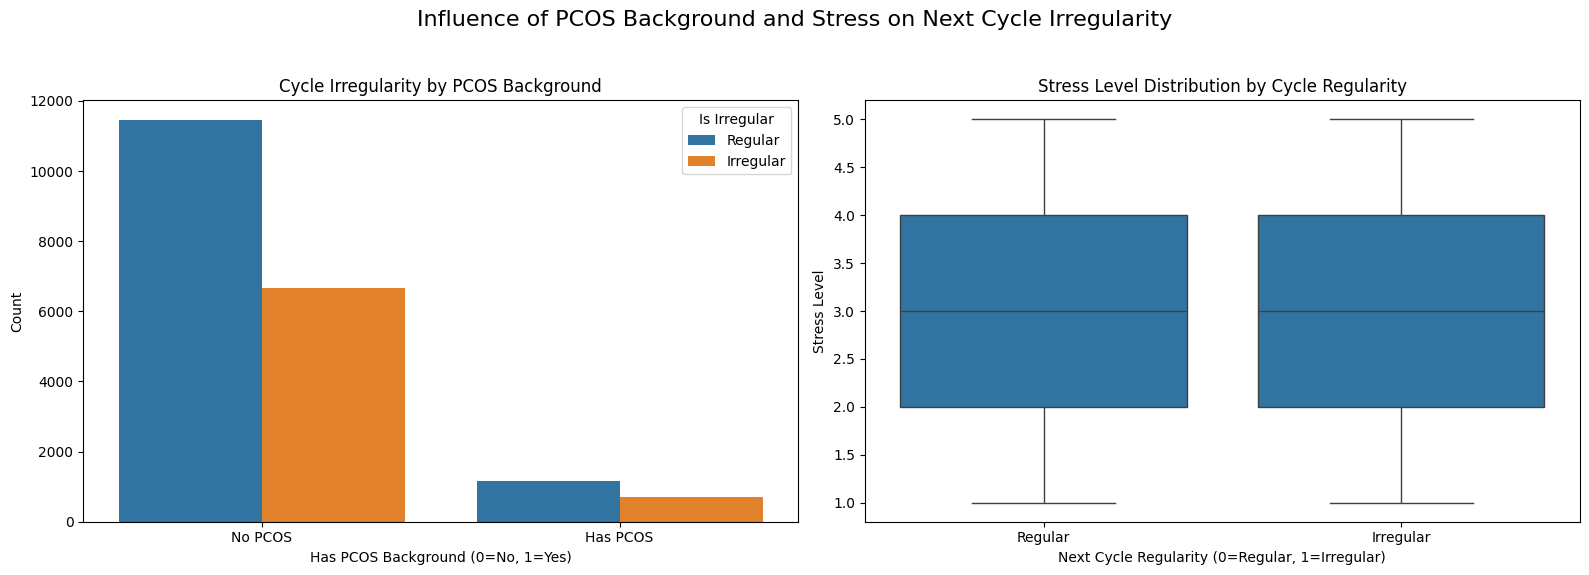

In [ ]:
# its very important ; cause pcos user have equal chance of having irregular cycle
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Influence of PCOS Background and Stress on Next Cycle Irregularity', fontsize=16)

# Count plot for Has_PCOS_Background vs Next_Is_Irregular
sns.countplot(x='Has_PCOS_Background', hue='Next_Is_Irregular', data=df, ax=axes[0])
axes[0].set_title('Cycle Irregularity by PCOS Background')
axes[0].set_xlabel('Has PCOS Background (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticks([0, 1], ['No PCOS', 'Has PCOS'])
axes[0].legend(title='Is Irregular', labels=['Regular', 'Irregular'])

# Box plot for Stress_Level vs Next_Is_Irregular
sns.boxplot(x='Next_Is_Irregular', y='Stress_Level', data=df, ax=axes[1])
axes[1].set_title('Stress Level Distribution by Cycle Regularity')
axes[1].set_xlabel('Next Cycle Regularity (0=Regular, 1=Irregular)')
axes[1].set_ylabel('Stress Level')
axes[1].set_xticks([0, 1], ['Regular', 'Irregular'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
print("Unique values in 'Diet_Type' column:")
print(df['Diet_Type'].unique())

print("\nValue counts for 'Diet_Type' column:")
print(df['Diet_Type'].value_counts())

Unique values in 'Diet_Type' column:
[2 3 1 0]

Value counts for 'Diet_Type' column:
Diet_Type
2    5052
3    5032
1    5004
0    4912
Name: count, dtype: int64


In [ ]:
# Apply one-hot encoding to 'Diet_Type'
df = pd.get_dummies(df, columns=['Diet_Type'], prefix='Diet')

display(df.head())
print(df.columns.tolist())

,Age,BMI,Age_At_Menarche,Family_History_Irregular,Has_PCOS_Background,Prev_1_Cycle_Length,Prev_2_Cycle_Length,Prev_3_Cycle_Length,Prev_1_Irregular_Flag,Prev_2_Irregular_Flag,...,Symptom_Bloating_Current,Symptom_Mood_Swings_Current,Symptom_Acne_Current,Next_Cycle_Length,Next_Is_Irregular,Next_Period_Length,Diet_0,Diet_1,Diet_2,Diet_3
0,24,31.6,15,0,0,0,0,0,0,0,...,0,0,0,34,0,5,False,False,True,False
1,24,31.6,15,0,0,34,0,0,0,0,...,0,1,0,34,0,6,False,False,False,True
2,24,31.6,15,0,0,34,34,0,0,0,...,0,1,1,31,0,6,False,False,True,False
3,24,31.6,15,0,0,31,34,34,0,0,...,1,0,1,32,1,8,False,True,False,False
4,24,31.6,15,0,0,32,31,34,1,0,...,0,0,0,32,0,5,False,False,False,True


['Age', 'BMI', 'Age_At_Menarche', 'Family_History_Irregular', 'Has_PCOS_Background', 'Prev_1_Cycle_Length', 'Prev_2_Cycle_Length', 'Prev_3_Cycle_Length', 'Prev_1_Irregular_Flag', 'Prev_2_Irregular_Flag', 'Prev_3_Irregular_Flag', 'Prev_1_Period_Length', 'Prev_2_Period_Length', 'Prev_3_Period_Length', 'Exercise_Frequency', 'Sleep_Hours', 'Stress_Level', 'Symptom_Cramps_Current', 'Symptom_Headache_Current', 'Symptom_Fatigue_Current', 'Symptom_Bloating_Current', 'Symptom_Mood_Swings_Current', 'Symptom_Acne_Current', 'Next_Cycle_Length', 'Next_Is_Irregular', 'Next_Period_Length', 'Diet_0', 'Diet_1', 'Diet_2', 'Diet_3']


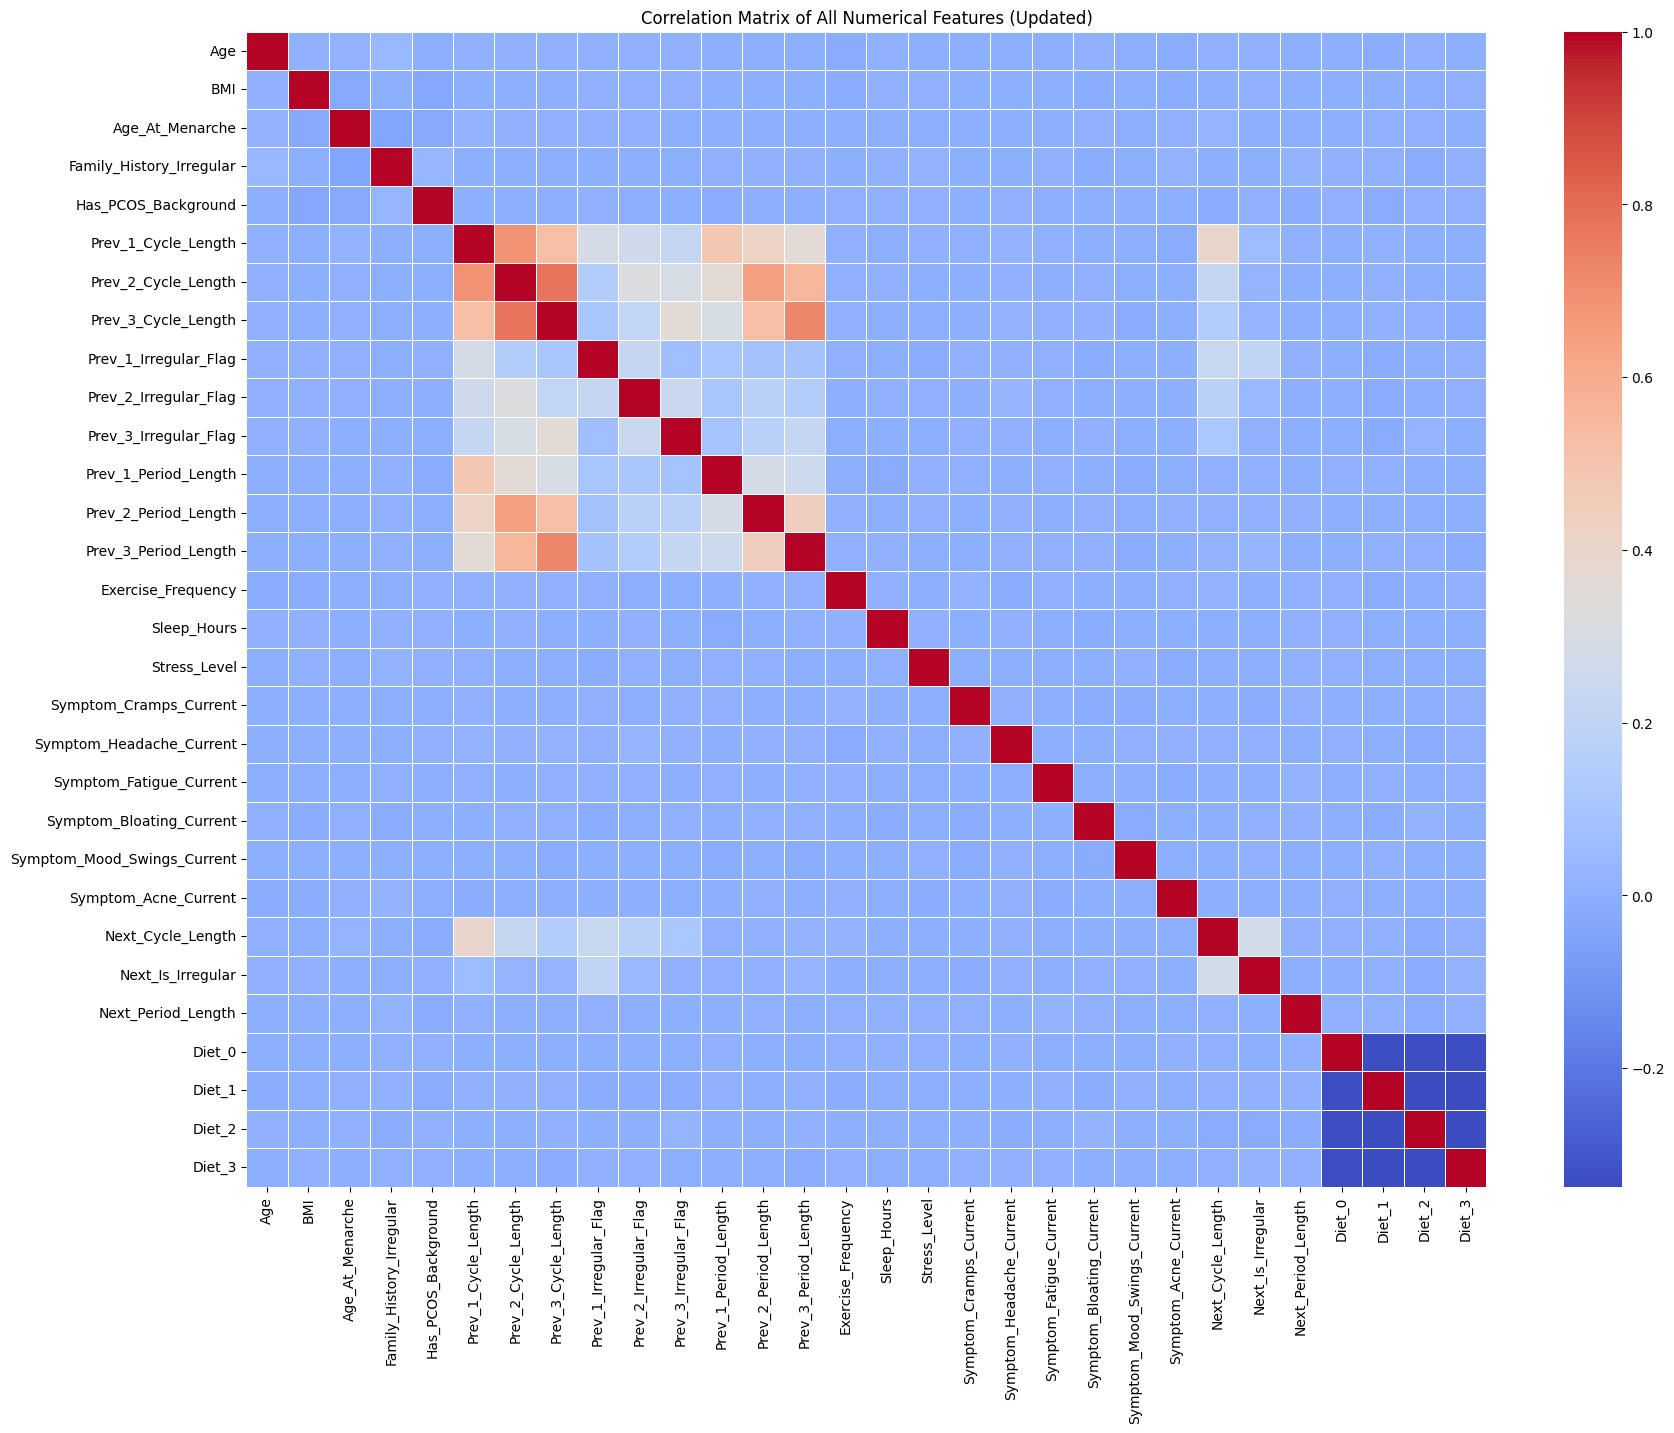

In [ ]:
#improtant maxium are related to,most don't have a strong linear relationship with each other or with the next cycle length in this dataset.
# this is due to user is  new to app
plt.figure(figsize=(20, 15)) # Increased figure size for better readability with more columns
correlation_matrix_updated = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix_updated, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Numerical Features (Updated)')
plt.show()

In [ ]:
threshold = 0.9
highly_correlated_pairs = []

# Get the absolute correlation matrix
abs_corr_matrix = correlation_matrix_updated.abs()

# Iterate through the upper triangle of the correlation matrix
for i in range(len(abs_corr_matrix.columns)):
    for j in range(i + 1, len(abs_corr_matrix.columns)):
        if abs_corr_matrix.iloc[i, j] > threshold:
            col1 = abs_corr_matrix.columns[i]
            col2 = abs_corr_matrix.columns[j]
            highly_correlated_pairs.append((col1, col2, abs_corr_matrix.iloc[i, j]))

if highly_correlated_pairs:
    print(f"Found {len(highly_correlated_pairs)} pairs of highly correlated features (absolute correlation > {threshold}):")
    for col1, col2, corr_val in highly_correlated_pairs:
        print(f"- {col1} and {col2} with correlation: {corr_val:.2f}")
else:
    print(f"No pairs of highly correlated features found above the threshold of {threshold}.")

No pairs of highly correlated features found above the threshold of 0.9.


After the multicollinearity check, no features were identified to be dropped based on the 0.9 threshold.

### Further Visualizations for Next Cycle Length and Irregularity

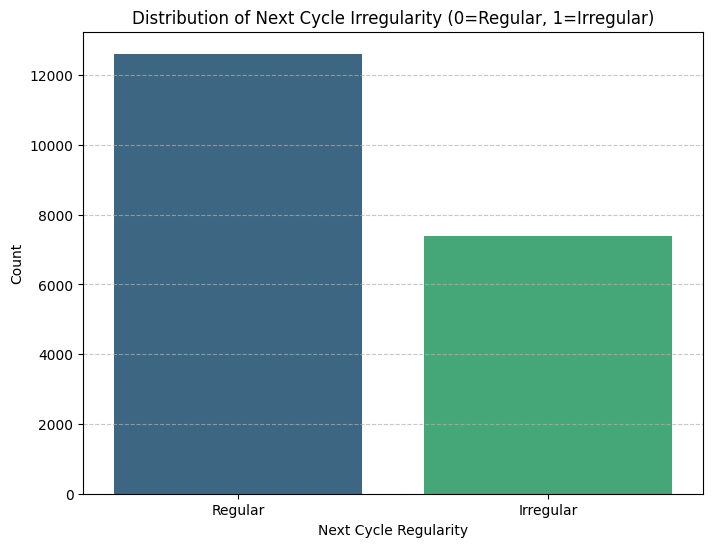

In [ ]:
# it shows most are of regular users in traning we might get good but in reality we may get worse
# 1. Distribution of Next_Is_Irregular
plt.figure(figsize=(8, 6))
sns.countplot(x='Next_Is_Irregular', data=df, hue='Next_Is_Irregular', palette='viridis', legend=False)
plt.title('Distribution of Next Cycle Irregularity (0=Regular, 1=Irregular)')
plt.xlabel('Next Cycle Regularity')
plt.ylabel('Count')
plt.xticks([0, 1], ['Regular', 'Irregular'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This count plot helps us understand the balance of regular vs. irregular cycles in our dataset. Now let's visualize the relationship between `Next_Cycle_Length` and its most strongly correlated feature, `Prev_1_Cycle_Length`.

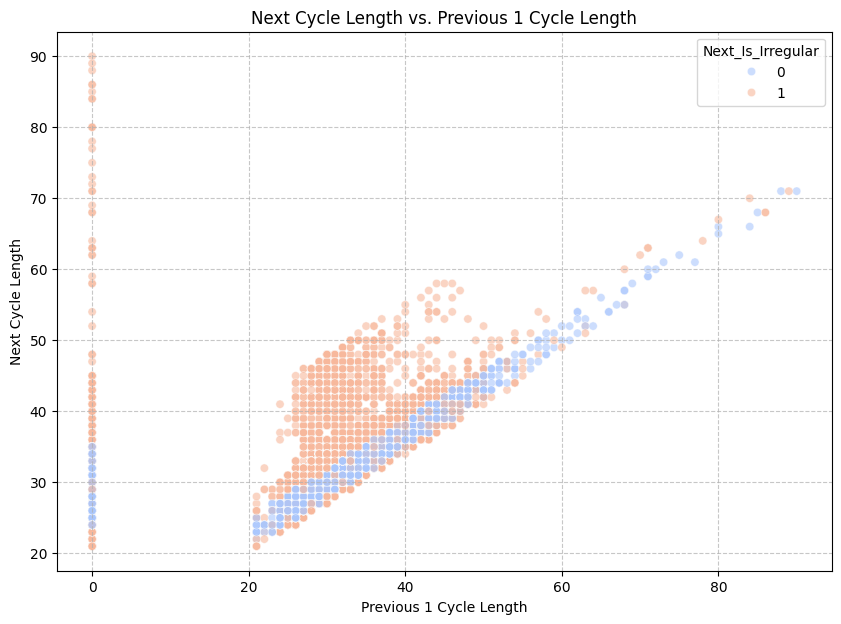

In [ ]:
# same as previous bar cart , regular are more
# 2. Scatter plot: Next_Cycle_Length vs Prev_1_Cycle_Length (strongest positive correlation)
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Prev_1_Cycle_Length', y='Next_Cycle_Length', data=df, hue='Next_Is_Irregular', palette='coolwarm', alpha=0.6)
plt.title('Next Cycle Length vs. Previous 1 Cycle Length')
plt.xlabel('Previous 1 Cycle Length')
plt.ylabel('Next Cycle Length')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


The scatter plot visually confirms the positive correlation between previous and next cycle lengths, and also allows us to see if irregularity plays a role in this relationship. Next, let's look at `Next_Cycle_Length` in relation to `Has_PCOS_Background`, as PCOS is a significant factor.

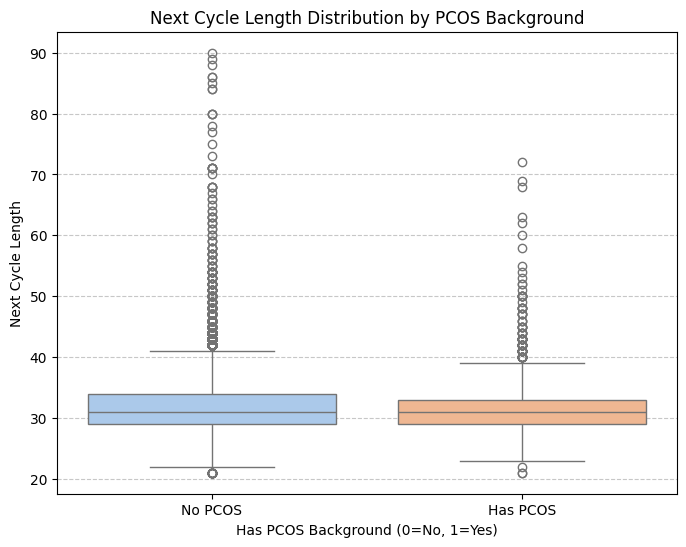

In [ ]:
#more outlier are due to more data of regular data
# 3. Box plot: Next_Cycle_Length vs Has_PCOS_Background
plt.figure(figsize=(8, 6))
sns.boxplot(x='Has_PCOS_Background', y='Next_Cycle_Length', data=df, palette='pastel', hue='Has_PCOS_Background', legend=False)
plt.title('Next Cycle Length Distribution by PCOS Background')
plt.xlabel('Has PCOS Background (0=No, 1=Yes)')
plt.ylabel('Next Cycle Length')
plt.xticks([0, 1], ['No PCOS', 'Has PCOS'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This box plot helps us understand if the presence of PCOS background leads to a different distribution in `Next_Cycle_Length`. Finally, let's examine `Next_Is_Irregular` with `Family_History_Irregular`.

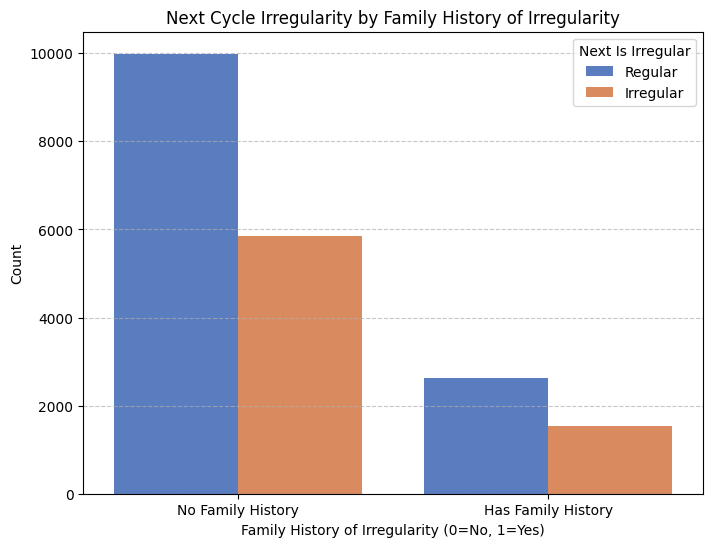

In [ ]:
# no need avoid it
# 4. Count plot: Next_Is_Irregular vs Family_History_Irregular
plt.figure(figsize=(8, 6))
sns.countplot(x='Family_History_Irregular', hue='Next_Is_Irregular', data=df, palette='muted')
plt.title('Next Cycle Irregularity by Family History of Irregularity')
plt.xlabel('Family History of Irregularity (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Family History', 'Has Family History'])
plt.legend(title='Next Is Irregular', labels=['Regular', 'Irregular'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Average Period Lengths Across Ages (Approximation of Time Series Trend)

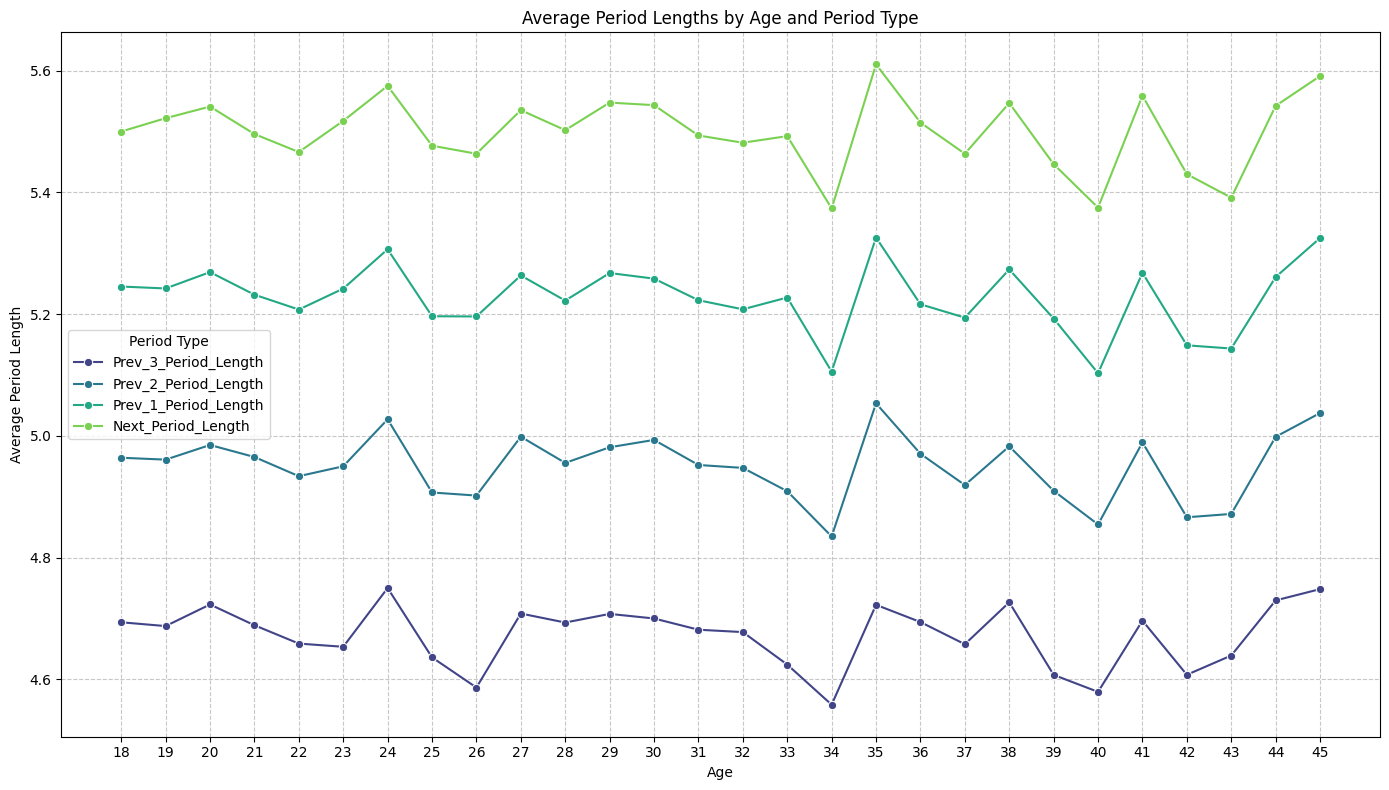

In [ ]:
# yo pani important cha cause age sange period kasari  related cha vanera Consistency of Cycle Lengths ko age ma hun cha
#Differences between 'Previous' and 'Next badi kun age group ma hudo raicha


# To visualize 'time series' like trends across age for period lengths,
# we'll melt the relevant columns and then plot their averages.

# Select relevant columns for period lengths and Age
period_length_cols = [
    'Age',
    'Prev_3_Period_Length',
    'Prev_2_Period_Length',
    'Prev_1_Period_Length',
    'Next_Period_Length'
]

df_period_lengths = df[period_length_cols].copy()

# Melt the DataFrame to long format for plotting
df_melted_periods = df_period_lengths.melt(
    id_vars=['Age'],
    value_vars=[
        'Prev_3_Period_Length',
        'Prev_2_Period_Length',
        'Prev_1_Period_Length',
        'Next_Period_Length'
    ],
    var_name='Period_Type',
    value_name='Period_Length'
)

# Group by Age and Period_Type to get the mean period length
average_periods_by_age = df_melted_periods.groupby(['Age', 'Period_Type'])['Period_Length'].mean().reset_index()

# Define a custom order for 'Period_Type' for better plotting
period_order = ['Prev_3_Period_Length', 'Prev_2_Period_Length', 'Prev_1_Period_Length', 'Next_Period_Length']
average_periods_by_age['Period_Type'] = pd.Categorical(
    average_periods_by_age['Period_Type'], categories=period_order, ordered=True
)

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=average_periods_by_age.sort_values(by=['Age', 'Period_Type']),
    x='Age',
    y='Period_Length',
    hue='Period_Type',
    marker='o',
    palette='viridis'
)
plt.title('Average Period Lengths by Age and Period Type')
plt.xlabel('Age')
plt.ylabel('Average Period Length')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(df['Age'].unique().astype(int))
plt.legend(title='Period Type')
plt.tight_layout()
plt.show()


# Additional Analysis Added
These sections strengthen the notebook for proposal defense.

In [ ]:
# 1. Target Class Distribution (%)
target='Next_Is_Irregular'
if target in df.columns:
    pct=df[target].value_counts(normalize=True).mul(100).round(2)
    print(pct)
    import matplotlib.pyplot as plt
    pct.plot(kind='bar')
    plt.title('Target Distribution (%)')
    plt.ylabel('Percentage')
    plt.show()


In [ ]:
# 2. Outlier Detection (Numeric Features)
import matplotlib.pyplot as plt
num_cols=df.select_dtypes(include='number').columns
for c in num_cols[:6]:   # first few numeric columns
    plt.figure(figsize=(5,2))
    plt.boxplot(df[c].dropna(), vert=False)
    plt.title(f'Boxplot: {c}')
    plt.show()


In [ ]:
# 3. Random Forest Feature Importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

target='Next_Is_Irregular'
if target in df.columns:
    X=df.drop(columns=[target])
    X=pd.get_dummies(X, drop_first=True)
    y=df[target]
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
    rf=RandomForestClassifier(random_state=42)
    rf.fit(X_train,y_train)
    imp=(pd.Series(rf.feature_importances_,index=X.columns)
           .sort_values(ascending=False).head(15))
    print(imp)
    import matplotlib.pyplot as plt
    imp.sort_values().plot(kind='barh')
    plt.title('Top 15 Feature Importances')
    plt.tight_layout()
    plt.show()


## Suggested Defense Notes

- User_ID removed because it is an identifier and has no predictive value.
- One-hot encoding is used for nominal categorical variables.
- Random Forest and XGBoost do not require feature scaling.
- Feature importance is reported in addition to correlation because nonlinear models may identify important variables with weak linear correlation.
- Outlier inspection and target distribution analysis were added to improve data quality assessment.
